In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
env = gym.make("CartPole-v1")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


In [3]:
n_bins = 10

bins = [
    np.linspace(-4.8, 4.8, n_bins),          # cart position
    np.linspace(-4.0, 4.0, n_bins),          # cart velocity
    np.linspace(-0.418, 0.418, n_bins),      # pole angle
    np.linspace(-4.0, 4.0, n_bins)           # pole angular velocity
]

In [4]:
def discretize_state(state):
    indices = []
    for i, value in enumerate(state):
        idx = np.digitize(value, bins[i])
        idx = min(max(idx, 0), n_bins)
        indices.append(idx)
    return tuple(indices)

In [5]:
q_table = np.zeros((n_bins + 1, n_bins + 1, n_bins + 1, n_bins + 1, env.action_space.n))

alpha = 0.1
gamma = 0.99
epsilon = 1.0
episodes = 3000

rewards_per_episode = []

In [6]:
for episode in range(episodes):
    state, _ = env.reset()
    state = discretize_state(state)
    done = False
    total_reward = 0

    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = discretize_state(next_state)
        done = terminated or truncated

        current_q = q_table[state][action]
        best_next_q = np.max(q_table[next_state])
        target = reward + gamma * best_next_q

        q_table[state][action] = current_q + alpha * (target - current_q)

        state = next_state
        total_reward += reward

    rewards_per_episode.append(total_reward)
    epsilon = max(0.05, epsilon * 0.995)

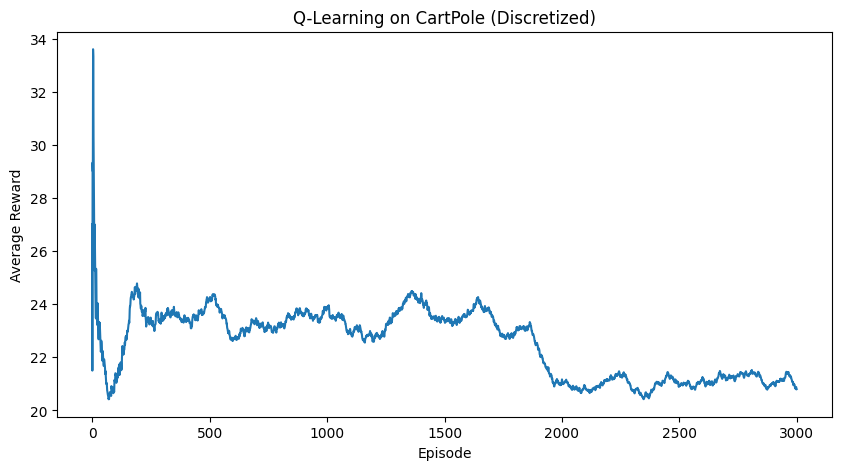

In [7]:
window = 100
avg_rewards = [
    np.mean(rewards_per_episode[max(0, i - window):i + 1])
    for i in range(len(rewards_per_episode))
]

plt.figure(figsize=(10, 5))
plt.plot(avg_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning on CartPole (Discretized)")
plt.show()

In [8]:
state, _ = env.reset()
state = discretize_state(state)
done = False
total_reward = 0.0

while not done:
    action = np.argmax(q_table[state])
    next_state, reward, terminated, truncated, _ = env.step(action)
    next_state = discretize_state(next_state)
    done = terminated or truncated
    state = next_state
    total_reward += float(reward)

print("Test reward:", total_reward)

Test reward: 23.0
